In [1]:
import pandas as pd
from skimpy import skim
from dfsummary import dfsummary
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error
import numpy as np
from sklearn.metrics import r2_score
import pickle

In [2]:
boston = pd.read_csv("dataset/BostonHousing.csv")
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
print(boston)

        crim    zn  indus  chas    nox     rm   age     dis  rad  tax  \
0    0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296   
1    0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242   
2    0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242   
3    0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222   
4    0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...  ...   
501  0.06263   0.0  11.93     0  0.573  6.593  69.1  2.4786    1  273   
502  0.04527   0.0  11.93     0  0.573  6.120  76.7  2.2875    1  273   
503  0.06076   0.0  11.93     0  0.573  6.976  91.0  2.1675    1  273   
504  0.10959   0.0  11.93     0  0.573  6.794  89.3  2.3889    1  273   
505  0.04741   0.0  11.93     0  0.573  6.030  80.8  2.5050    1  273   

     ptratio       b  lstat  medv  
0       15.3  396.90   4.98  24.0  
1       17.8  396.90   9.14  21.6  
2       17.8  3

# Preparing the dataset

In [4]:
boston.isna().sum() / len(boston) * 100

crim       0.000000
zn         0.000000
indus      0.000000
chas       0.000000
nox        0.000000
rm         0.988142
age        0.000000
dis        0.000000
rad        0.000000
tax        0.000000
ptratio    0.000000
b          0.000000
lstat      0.000000
medv       0.000000
dtype: float64

In [5]:
skim(boston)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 506    │ │ float64     │ 11    │                                                          │
│ │ Number of columns │ 14     │ │ int64       │ 3     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━┳━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column  ┃ NA ┃ NA %               ┃ mean    ┃ sd     ┃ p0      ┃ p25     ┃ p50    ┃ p75   ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━╇━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │  crim   │  0 │                  0 │   3.614 │  8.602 │ 0.00632 │ 0.08204 │ 0.2565 │ 3.677 │ 88.98 │   ▇    │  │
│ │   zn    │  0 │                  0 │   11.36 │  23.32 │       0 │       0 │      0 │  12.5 │   100 │   ▇▁   │  │
│ │  indus  │  0 │                  0 │   11.14 │   6.86 │    0.46 │    5.19 │   9.69 │  18.1 │ 27.74 │ ▇▇▃▇▃▁ │  │
│ │  chas   │  0 │                  0 │ 0.06917 │  0.254 │       0 │       0 │      0 │     0 │     1 │ ▇    ▁ │  │
│ │   nox   │  0 │                  0 │  0.5547 │ 0.1159 │   0.385 │   0.449 │  0.538 │ 0.624 │ 0.871 │ ▇▇▅▃▂▁ │  │
│ │   rm    │  5 │ 0.9881422924901185 │   6.284 │ 0.7056 │   3.561 │   5.884 │  6.208 │ 6.625 │  8.78 │  ▁▇▇▂▁ │  │
│ │   age   │  0 │                  0 │   68.57 │  28.15 │     2.9 │   45.02 │   77.5 │ 94.07 │   100 │ ▁▂▂▂▃▇ │  │
│ │   dis   │  0 │                  0 │   3.795 │  2.106 │    1.13 │     2.1 │  3.207 │ 5.188 │ 12.13 │  ▇▅▃▁  │  │
│ │   rad   │  0 │                  0 │   9.549 │  8.707 │       1 │       4 │      5 │    24 │    24 │ ▇▇   ▆ │  │
│ │   tax   │  0 │                  0 │   408.2 │  168.5 │     187 │     279 │    330 │   666 │   711 │ ▅▇▅  ▆ │  │
│ │ ptratio │  0 │                  0 │   18.46 │  2.165 │    12.6 │    17.4 │  19.05 │  20.2 │    22 │ ▁▂▂▅▇▂ │  │
│ │    b    │  0 │                  0 │   356.7 │  91.29 │    0.32 │   375.4 │  391.4 │ 396.2 │ 396.9 │      ▇ │  │
│ │  lstat  │  0 │                  0 │   12.65 │  7.141 │    1.73 │    6.95 │  11.36 │ 16.96 │ 37.97 │ ▇▇▆▂▁  │  │
│ │  medv   │  0 │                  0 │   22.53 │  9.197 │       5 │   17.02 │   21.2 │    25 │    50 │ ▂▇▇▃▁▁ │  │
│ └─────────┴────┴────────────────────┴─────────┴────────┴─────────┴─────────┴────────┴───────┴───────┴────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [6]:
def dataframe_corr(dataframe, corr_name = 'pearson'):
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(dataframe.corr(method=corr_name), annot=True, cmap="coolwarm")
    plt.show()

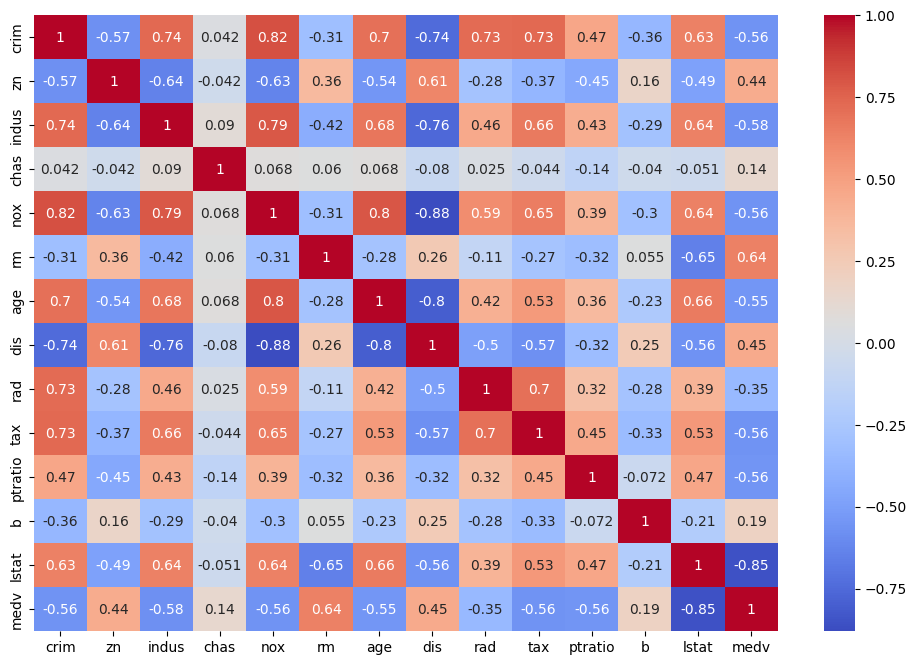

In [7]:
dataframe_corr(boston, 'spearman')

In [8]:
boston.dropna(inplace=True)

c:\Users\hassa\Documents\Projects\Boston House Pricing\boston_house_pricing\.venv\Lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


<Axes: xlabel='zn', ylabel='medv'>

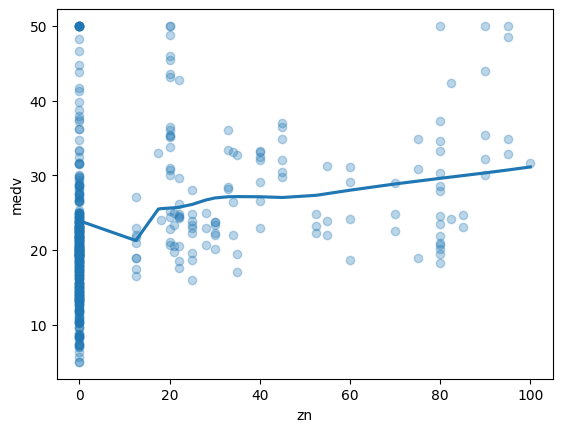

In [9]:
sns.regplot(data=boston, x="zn", y="medv", lowess=True, scatter_kws={"alpha": 0.3})

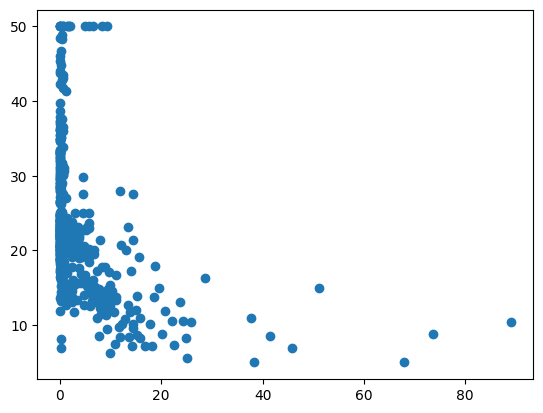

In [10]:
plt.scatter(boston['crim'], boston['medv'])

<Axes: xlabel='rm', ylabel='medv'>

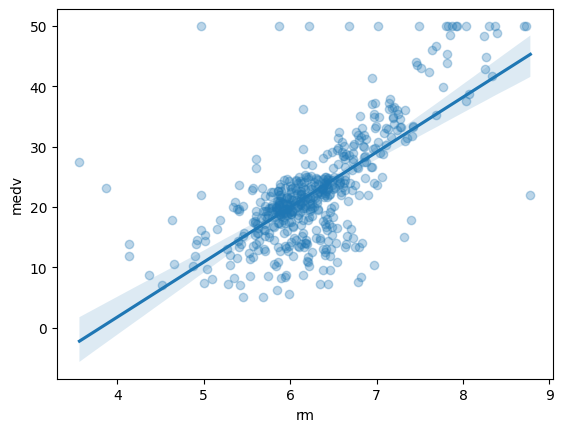

In [11]:
sns.regplot(data=boston, x="rm", y="medv",  scatter_kws={"alpha": 0.3})

<Axes: xlabel='lstat', ylabel='medv'>

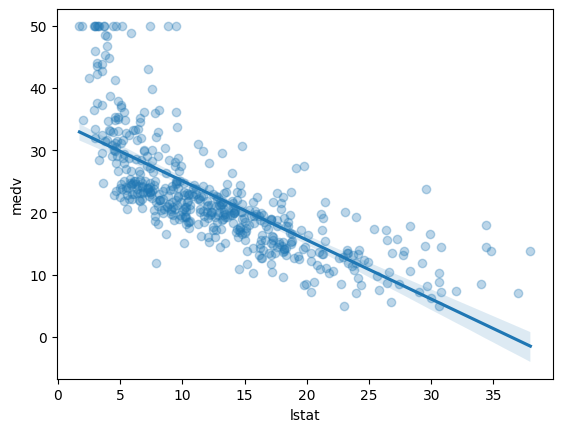

In [12]:
# Observation: Linear Relationship and has a negative correlation

sns.regplot(data=boston, x="lstat", y="medv",  scatter_kws={"alpha": 0.3})

<Axes: xlabel='chas', ylabel='medv'>

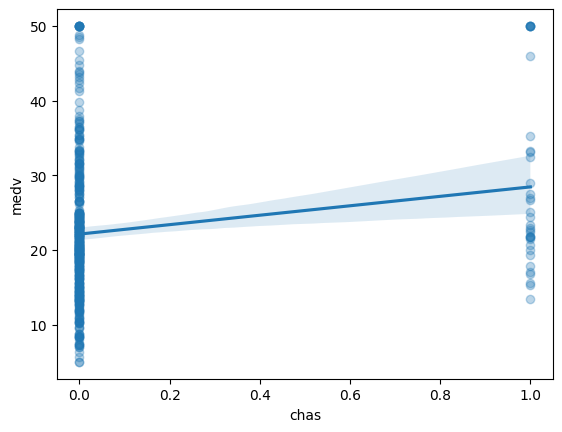

In [13]:
sns.regplot(data=boston, x="chas", y="medv",  scatter_kws={"alpha": 0.3})

<Axes: xlabel='ptratio', ylabel='medv'>

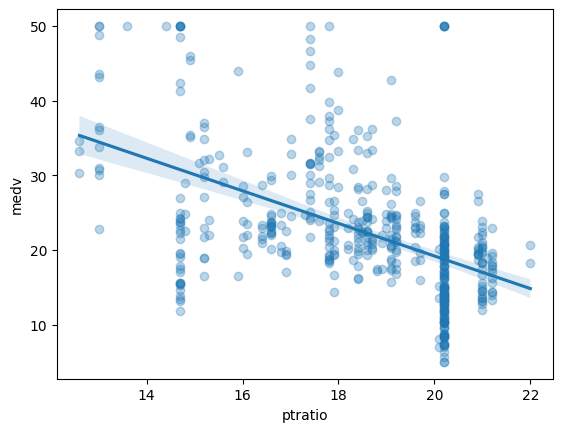

In [14]:
# Observation: Inverse Relationship and has a negative correlation

sns.regplot(data=boston, x="ptratio", y="medv",  scatter_kws={"alpha": 0.3})

# Preparing dataset for model training

In [15]:
# Independent and Dependent features

X = boston.iloc[:,:-1]
y = boston.iloc[:,-1]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [17]:
# Standardize the dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

In [18]:
X_test_scaled = scaler.transform(X_test)

In [19]:
pickle.dump(scaler, open('scaling.pkl', 'wb'))

# Model Training

In [ ]:
rg = LinearRegression()

In [ ]:
rg.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# print the coefficients
print("Coefficients:", rg.coef_)

Coefficients: [-0.81333048  1.25793481  0.55901585  0.62921378 -1.90632294  2.57817719
  0.56191215 -2.87590127  2.74653476 -2.09048251 -2.03201533  1.20544035
 -4.54581734]


In [ ]:
print(rg.intercept_)

22.840285714285717


In [ ]:
rg.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

In [ ]:
# Map coefficients back to feature names
feature_names = X_train.columns  # your 13 Boston features
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': rg.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print(coef_df)

    feature  coefficient
12    lstat    -4.545817
7       dis    -2.875901
8       rad     2.746535
5        rm     2.578177
9       tax    -2.090483
10  ptratio    -2.032015
4       nox    -1.906323
1        zn     1.257935
11        b     1.205440
0      crim    -0.813330
3      chas     0.629214
6       age     0.561912
2     indus     0.559016


In [ ]:
# Prediction with test dataset
pred_price = rg.predict(X_test_scaled)

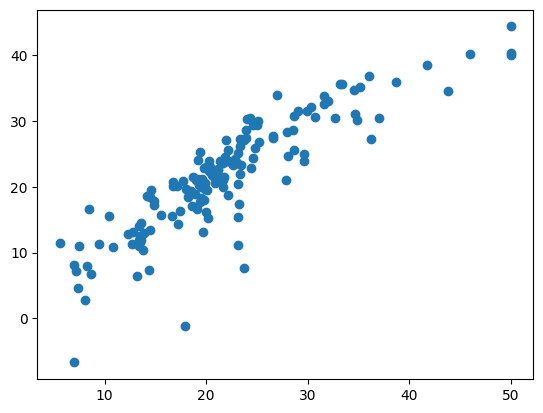

In [ ]:
# Plot a scatter plot for the prediction
plt.scatter(y_test, pred_price)

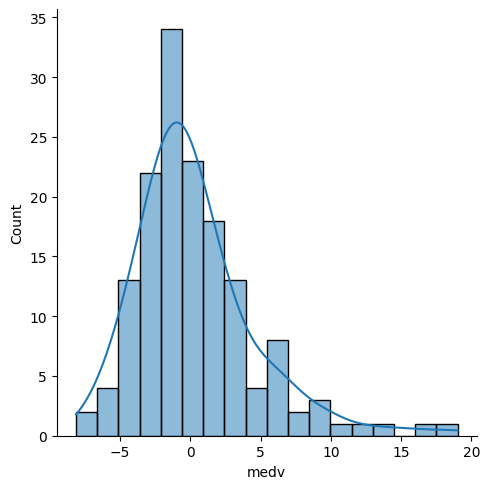

In [ ]:
# Prediction with residuals
residuals = y_test - pred_price
sns.displot(residuals, kde=True)

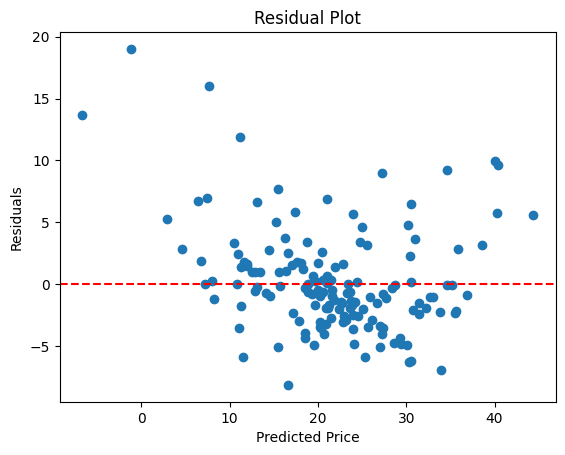

In [ ]:
# Scatter plot with respect to prediction and residuals
# Uniform distribution of residuals around zero indicates a good fit
plt.scatter(pred_price, residuals)
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

In [ ]:


print(mean_absolute_error(y_test, pred_price))
print(mean_squared_error(y_test, pred_price))
print(root_mean_squared_error(y_test, pred_price))
print(r2_score(y_test, pred_price))
print(np.sqrt(mean_squared_error(y_test, pred_price)))

3.0541387622304703
18.380869507282043
4.287291628438873
0.7509342231409273
4.287291628438873


In [ ]:
# R Square and Adjusted R Square

score = r2_score(y_test, pred_price)
print(score)

0.7509342231409273


In [ ]:
model = sm.OLS(y_train, sm.add_constant(X_train_scaled)).fit()
print(model.rsquared_adj)

0.7175760877131037


In [ ]:
sm_pred_test = model.predict(sm.add_constant(X_test_scaled))
sm_pred_train = model.predict(sm.add_constant(X_train_scaled))

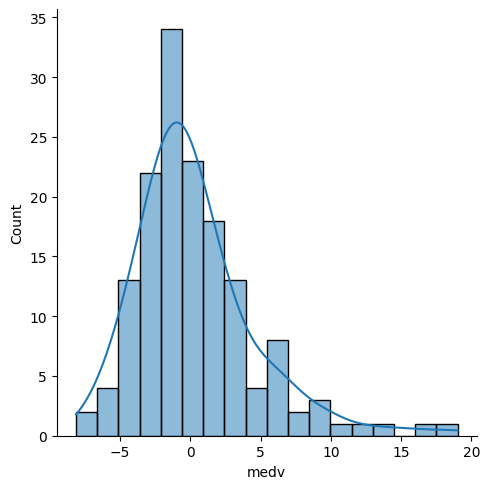

In [ ]:
# Prediction with residuals
sm_residuals = y_test - sm_pred_test
sns.displot(sm_residuals, kde=True)

In [ ]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.728
Model:                            OLS   Adj. R-squared:                  0.718
Method:                 Least Squares   F-statistic:                     69.21
Date:                Thu, 21 May 2026   Prob (F-statistic):           1.13e-86
Time:                        20:58:09   Log-Likelihood:                -1055.6
No. Observations:                 350   AIC:                             2139.
Df Residuals:                     336   BIC:                             2193.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.8403      0.269     84.789      0.0

# Pickling The Model file for Deployment

In [39]:
pickle.dump(rg, open('boston_price_model.pkl', 'wb'))

In [40]:
pickled_model = pickle.load(open('boston_price_model.pkl', 'rb'))

In [ ]:
boston.head(1).shape

(1, 14)

In [49]:
pickled_model.predict(scaler.transform(boston.head(1).drop('medv', axis=1).values.reshape(1, -1)))

c:\Users\hassa\Documents\Projects\Boston House Pricing\boston_house_pricing\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([30.32808565])

In [20]:
json_data = {
    "data": [
        {
            "CRIM": 0.00632,
            "ZN": 18.0,
            "INDUS": 2.31,
            "CHAS": 0.0,
            "NOX": 0.538,
            "RM": 6.575,
            "AGE": 65.2,
            "DIS": 4.0900,
            "RAD": 1.0,
            "TAX": 296,
            "PTRATIO": 15.3,
            "B": 396.90,
            "LSTAT": 4.98
        },
        {
            "CRIM": 0.02731,
            "ZN": 0.0,
            "INDUS": 7.07,
            "CHAS": 0.0,
            "NOX": 0.469,
            "RM": 6.421,
            "AGE": 78.9,
            "DIS": 4.9671,
            "RAD": 2.0,
            "TAX": 242,
            "PTRATIO": 17.8,
            "B": 396.90,
            "LSTAT": 9.14
        },
        {
            "CRIM": 0.15086,
            "ZN": 0.0,
            "INDUS": 27.74,
            "CHAS": 0.0,
            "NOX": 0.609,
            "RM": 5.454,
            "AGE": 92.7,
            "DIS": 1.9604,
            "RAD": 4.0,
            "TAX": 711,
            "PTRATIO": 20.1,
            "B": 395.09,
            "LSTAT": 18.06
        }
    ]
}

In [26]:
json_one_data = {
    "data": 
        {
            "CRIM": 0.00632,
            "ZN": 18.0,
            "INDUS": 2.31,
            "CHAS": 0.0,
            "NOX": 0.538,
            "RM": 6.575,
            "AGE": 65.2,
            "DIS": 4.0900,
            "RAD": 1.0,
            "TAX": 296,
            "PTRATIO": 15.3,
            "B": 396.90,
            "LSTAT": 4.98
        }
}

In [28]:
np.array((json_one_data['data'].values())).reshape(1, -1)

array([[dict_values([0.00632, 18.0, 2.31, 0.0, 0.538, 6.575, 65.2, 4.09, 1.0, 296, 15.3, 396.9, 4.98])]],
      dtype=object)

In [34]:
json_data

{'data': [{'CRIM': 0.00632,
   'ZN': 18.0,
   'INDUS': 2.31,
   'CHAS': 0.0,
   'NOX': 0.538,
   'RM': 6.575,
   'AGE': 65.2,
   'DIS': 4.09,
   'RAD': 1.0,
   'TAX': 296,
   'PTRATIO': 15.3,
   'B': 396.9,
   'LSTAT': 4.98},
  {'CRIM': 0.02731,
   'ZN': 0.0,
   'INDUS': 7.07,
   'CHAS': 0.0,
   'NOX': 0.469,
   'RM': 6.421,
   'AGE': 78.9,
   'DIS': 4.9671,
   'RAD': 2.0,
   'TAX': 242,
   'PTRATIO': 17.8,
   'B': 396.9,
   'LSTAT': 9.14},
  {'CRIM': 0.15086,
   'ZN': 0.0,
   'INDUS': 27.74,
   'CHAS': 0.0,
   'NOX': 0.609,
   'RM': 5.454,
   'AGE': 92.7,
   'DIS': 1.9604,
   'RAD': 4.0,
   'TAX': 711,
   'PTRATIO': 20.1,
   'B': 395.09,
   'LSTAT': 18.06}]}

In [33]:
records = json_data['data']
records

[{'CRIM': 0.00632,
  'ZN': 18.0,
  'INDUS': 2.31,
  'CHAS': 0.0,
  'NOX': 0.538,
  'RM': 6.575,
  'AGE': 65.2,
  'DIS': 4.09,
  'RAD': 1.0,
  'TAX': 296,
  'PTRATIO': 15.3,
  'B': 396.9,
  'LSTAT': 4.98},
 {'CRIM': 0.02731,
  'ZN': 0.0,
  'INDUS': 7.07,
  'CHAS': 0.0,
  'NOX': 0.469,
  'RM': 6.421,
  'AGE': 78.9,
  'DIS': 4.9671,
  'RAD': 2.0,
  'TAX': 242,
  'PTRATIO': 17.8,
  'B': 396.9,
  'LSTAT': 9.14},
 {'CRIM': 0.15086,
  'ZN': 0.0,
  'INDUS': 27.74,
  'CHAS': 0.0,
  'NOX': 0.609,
  'RM': 5.454,
  'AGE': 92.7,
  'DIS': 1.9604,
  'RAD': 4.0,
  'TAX': 711,
  'PTRATIO': 20.1,
  'B': 395.09,
  'LSTAT': 18.06}]

In [52]:
list(records[0])

['CRIM',
 'ZN',
 'INDUS',
 'CHAS',
 'NOX',
 'RM',
 'AGE',
 'DIS',
 'RAD',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT']

In [54]:
list(records[0].values())

[0.00632,
 18.0,
 2.31,
 0.0,
 0.538,
 6.575,
 65.2,
 4.09,
 1.0,
 296,
 15.3,
 396.9,
 4.98]

In [ ]:
np.array([list(record.values()) for record in records])

array([['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
        'TAX', 'PTRATIO', 'B', 'LSTAT'],
       ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
        'TAX', 'PTRATIO', 'B', 'LSTAT'],
       ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
        'TAX', 'PTRATIO', 'B', 'LSTAT']], dtype='<U7')